In [50]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
import sys

sys.path.append('..')
from config import DATA_PATH
from pathlib import Path
from utils import (
    find_audio_file,
    load_audio,
    bandpass_filter,
    load_spectrogram,
    quick_spectrogram,
    get_main_freq_traj,
    track_ridge_tfridge_like
)
np.random.seed(0)

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

import importlib
import utils
importlib.reload(utils)


import inspect
print(inspect.getsource(track_ridge_tfridge_like))

def track_ridge_tfridge_like(mag_usv, freqs_usv, active_bins, top_k=5, jump_penalty=1e-7):
    n_freq, n_time = mag_usv.shape
    candidates = []

    for t in range(n_time):
        if not active_bins[t]:
            candidates.append([])
            continue

        peaks, props = find_peaks(mag_usv[:, t])
        if len(peaks) == 0:
            peaks = np.array([np.argmax(mag_usv[:, t])])

        amps = mag_usv[peaks, t]
        best = peaks[np.argsort(amps)[-top_k:]]
        candidates.append(best)

    ridge = np.zeros(n_time)

    prev_freq = None

    for t in range(n_time):
        if len(candidates[t]) == 0:
            prev_freq = None
            continue

        best_score = -np.inf
        best_freq = 0

        for idx in candidates[t]:
            f = freqs_usv[idx]
            amp_score = np.log(mag_usv[idx, t] + 1e-12)

            if prev_freq is None:
                continuity_score = 0
            else:
                continuity_score = -jump_penalty * (f - pre

In [3]:
splits = {"train": TRAIN_PATH, "test": TEST_PATH}
file_records = []

for split_name, split_path in splits.items():
    wavs = list(split_path.glob("*.WAV"))
    for wav_path in wavs:
        file_records.append({
            "filename": wav_path.name,
            "split": split_name,
            "full_path": wav_path,
        })

file_df = pd.DataFrame(file_records)

print(file_df["split"].value_counts())
print(f"Total .WAV files: {len(file_df)}")

split
train    20265
test      2251
Name: count, dtype: int64
Total .WAV files: 22516


In [4]:
n_sample = 200
sample_df = file_df.sample(n=min(n_sample, len(file_df)), random_state=0)

info_rows = []
for _, row in sample_df.iterrows():
    info = sf.info(row["full_path"])
    info_rows.append({
        "filename": row["filename"],
        "split": row["split"],
        "samplerate": info.samplerate,
        "duration_s": info.duration,
        "channels": info.channels,
    })

info_df = pd.DataFrame(info_rows)
print("Unique sample rates found (Hz):", info_df["samplerate"].unique())
print("Unique channel counts found:", info_df["channels"].unique())
print(info_df.groupby("split")["duration_s"].describe())

Unique sample rates found (Hz): [250000]
Unique channel counts found: [1]
       count      mean       std       min       25%       50%       75%  \
split                                                                      
test    21.0  0.054480  0.032573  0.017604  0.033604  0.044804  0.064004   
train  179.0  0.060974  0.033029  0.009604  0.036804  0.051204  0.076804   

            max  
split            
test   0.147204  
train  0.172804  


In [21]:
n_check = 500
check_df = file_df.sample(n=min(n_check, len(file_df)), random_state=1)

issues = []
silence_thresh = 1e-4

for _, row in check_df.iterrows():
    try:
        a, s = load_audio(row["full_path"])
        if np.abs(a).max() < silence_thresh:
            issues.append({"filename": row["filename"], "split": row["split"], "issue": "near-silent"})
            continue
        _ = bandpass_filter(a, s, LOW_HZ_TYPICAL, HIGH_HZ_TYPICAL)
    except Exception as e:
        issues.append({"filename": row["filename"], "split": row["split"], "issue": f"error: {e}"})

issues_df = pd.DataFrame(issues)
print(f"Checked {len(check_df)} files, found {len(issues_df)} issues")
if len(issues_df) > 0:
    print(issues_df.groupby("split")["issue"].value_counts())
    issues_df.to_csv("flagged_files.csv", index=False)

Checked 500 files, found 500 issues
split  issue                                      
test   error: name 'LOW_HZ_TYPICAL' is not defined     42
train  error: name 'LOW_HZ_TYPICAL' is not defined    458
Name: count, dtype: int64


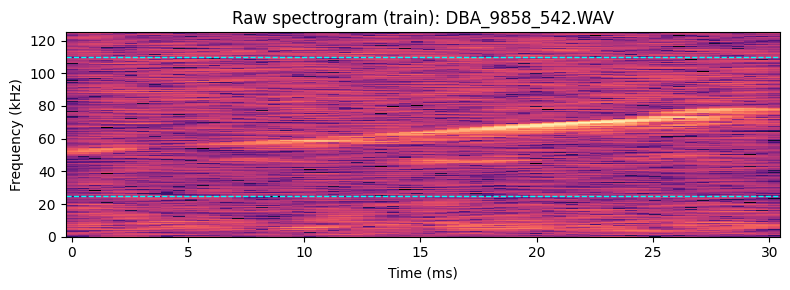

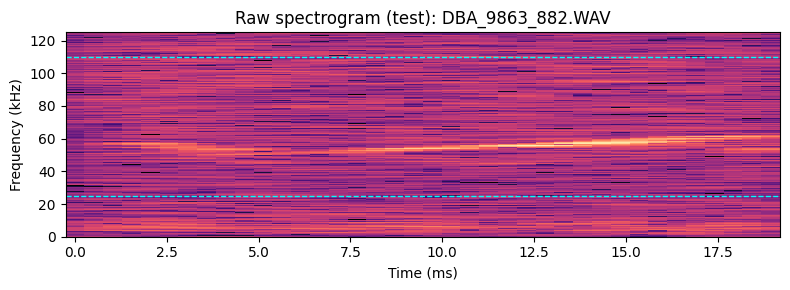

In [22]:
# checking if the audio files are already filtered / what raw files look like
for split_name in ["train", "test"]:
    sample_row = file_df[file_df["split"] == split_name].sample(1, random_state=2).iloc[0]

    a, s = load_audio(sample_row["full_path"])

    S_db, freqs, times_bg = quick_spectrogram(
        a,
        s,
        n_fft=1024,
        hop_length=128,
    )

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times_bg * 1000, freqs / 1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.ylim(0, 125)
    plt.axhline(25, color="cyan", linestyle="--", linewidth=1)
    plt.axhline(110, color="cyan", linestyle="--", linewidth=1)
    plt.title(f"Raw spectrogram ({split_name}): {sample_row['filename']}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (kHz)")
    plt.tight_layout()
    plt.show()

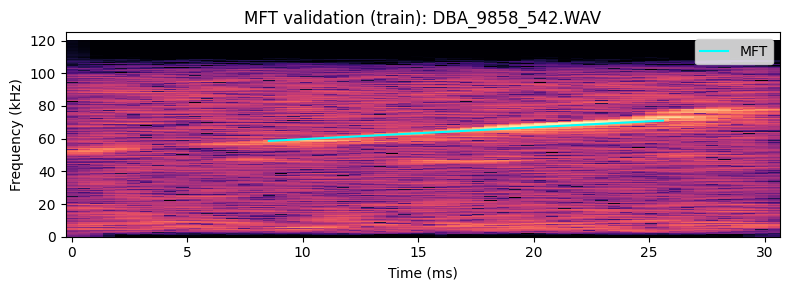

Detected active bins: 3 / 4


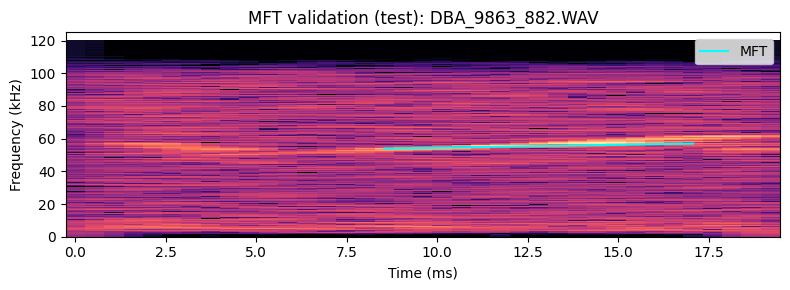

Detected active bins: 2 / 3


In [28]:
for split_name in ["train", "test"]:
    sample_row = file_df[file_df["split"] == split_name].sample(1, random_state=2).iloc[0]
    path = sample_row["full_path"]

    a, s = load_audio(path, target_sr=240000)
    filtered = bandpass_filter(a, s, low_hz=2500, high_hz=100000, order=3)

    S_db, freqs, times_bg = quick_spectrogram(filtered, s)

    times_traj, freq_traj, active_bins = get_main_freq_traj(path)

    plot_freq = np.where(freq_traj > 0, freq_traj, np.nan)

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times_bg * 1000, freqs / 1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.plot(times_traj * 1000, plot_freq / 1000, color="cyan", linewidth=1.5, label="MFT")

    plt.ylim(0, 125)
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (kHz)")
    plt.title(f"MFT validation ({split_name}): {sample_row['filename']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Detected active bins:", active_bins.sum(), "/", len(active_bins))

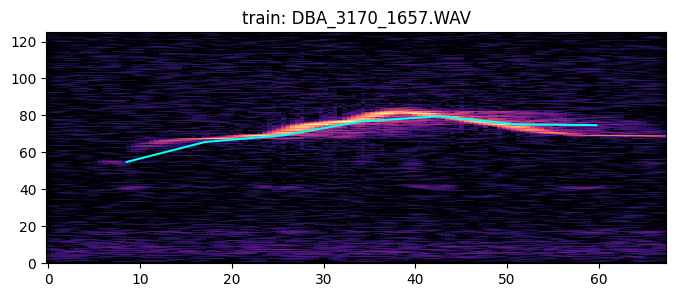

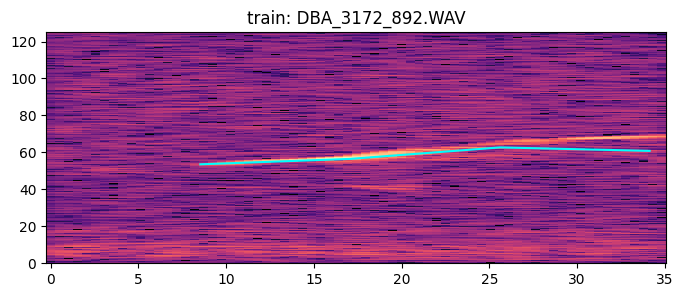

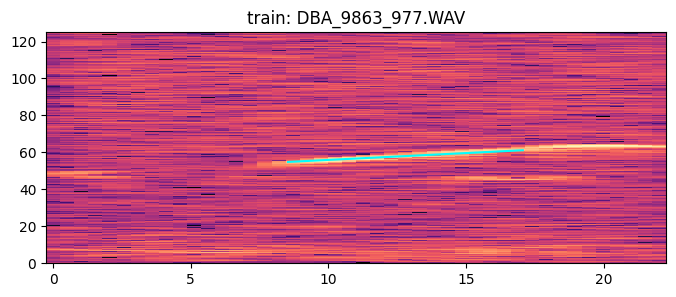

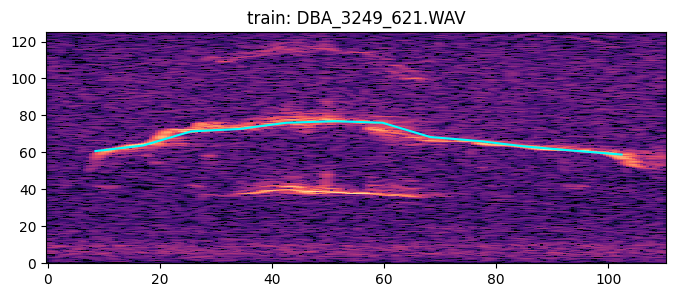

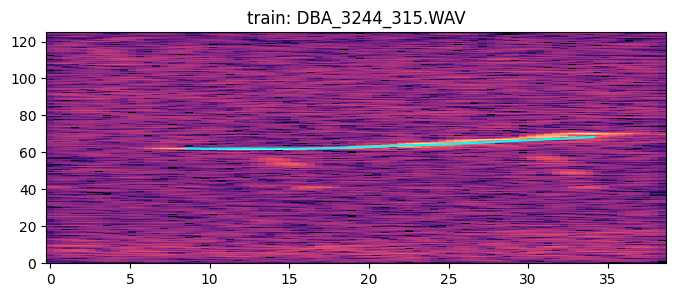

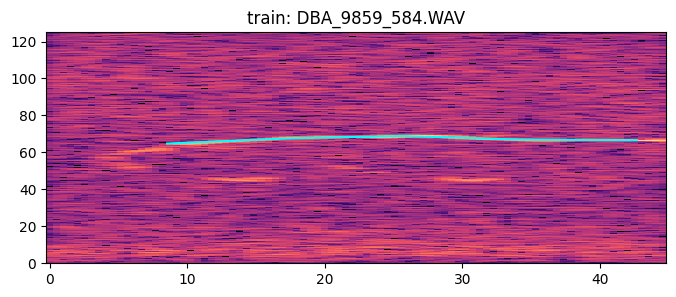

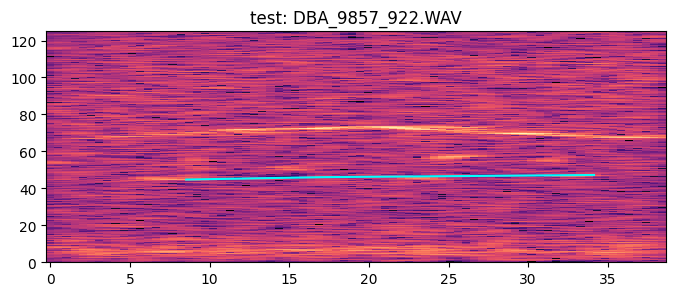

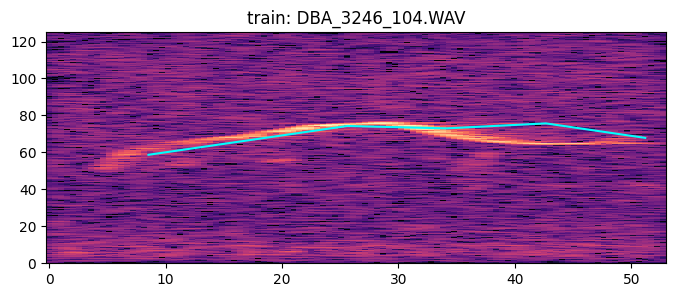

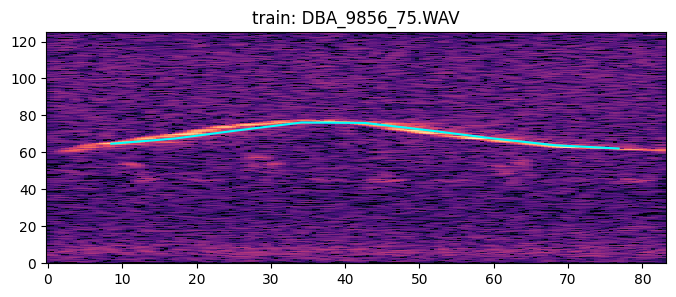

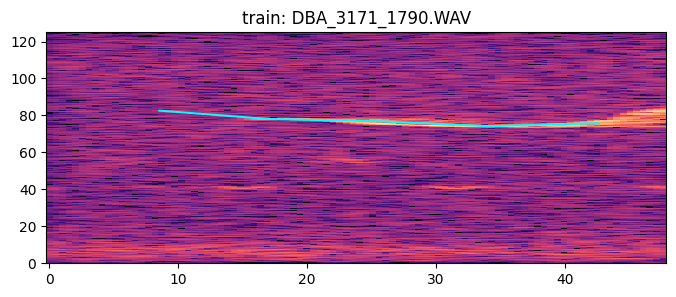

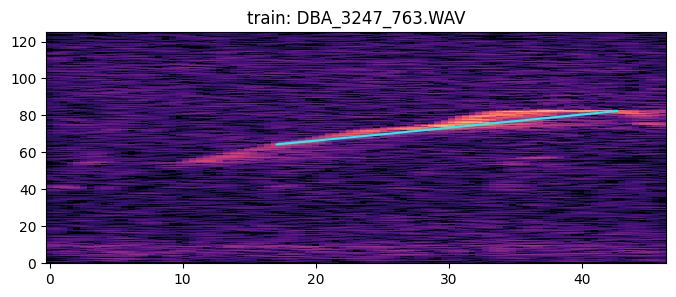

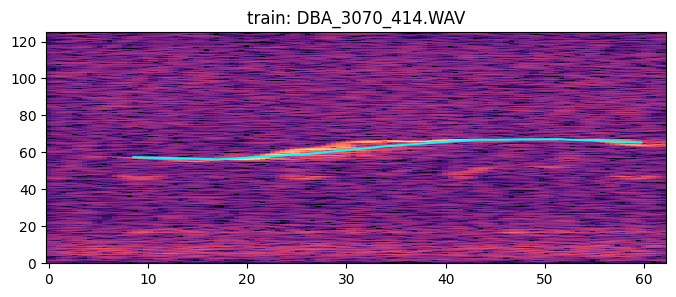

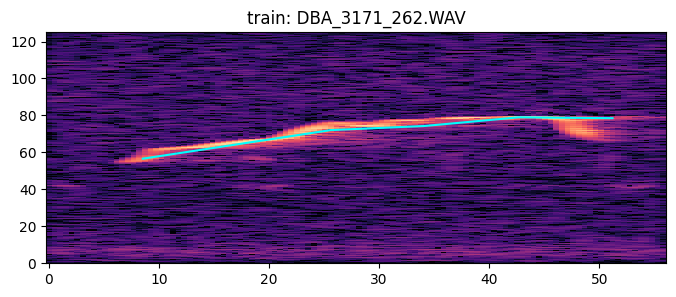

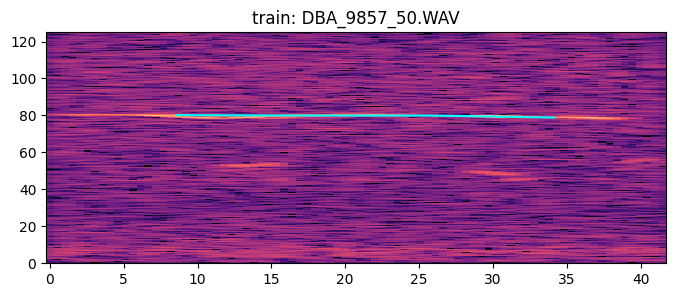

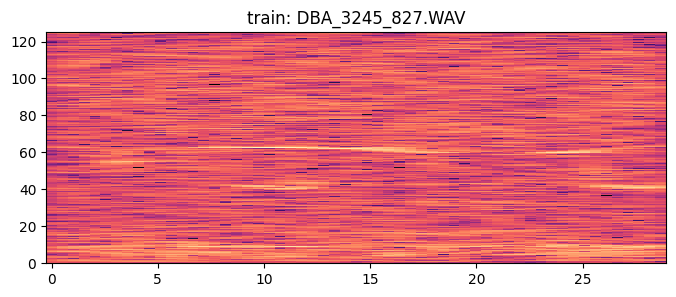

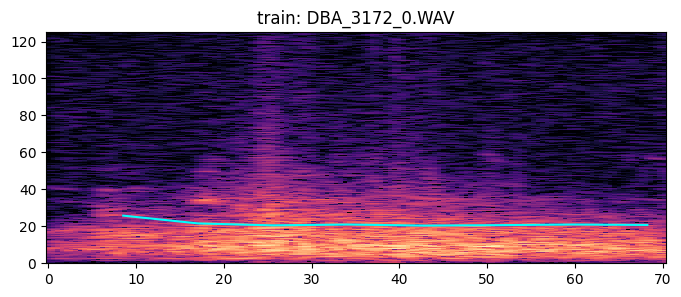

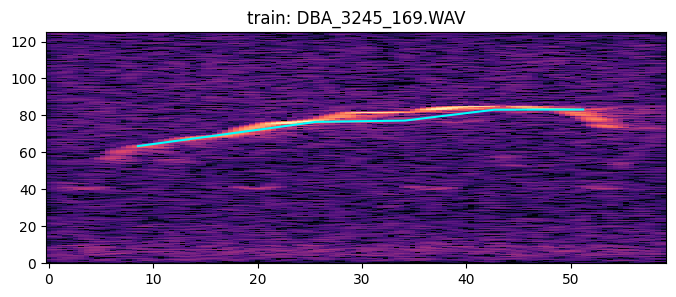

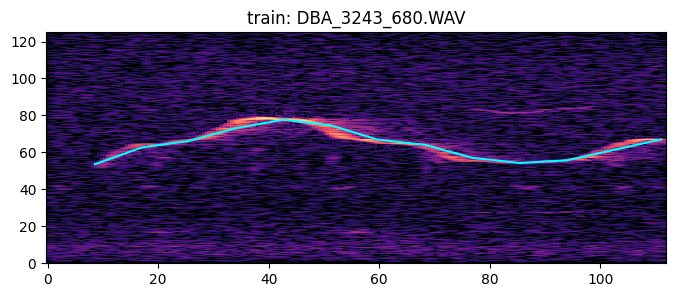

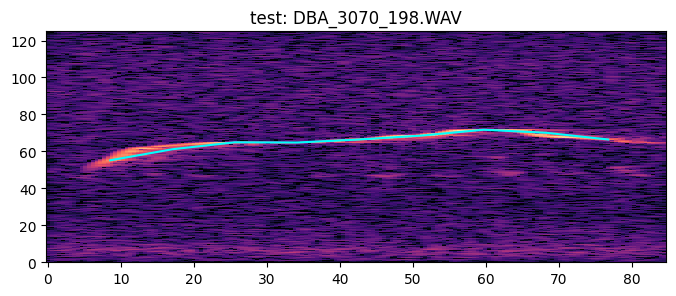

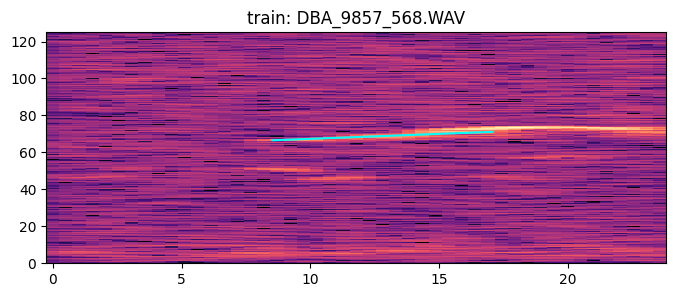

In [29]:
sample_check = file_df.sample(20, random_state=42)

for _, row in sample_check.iterrows():
    path = row["full_path"]

    a, s = load_audio(path)
    S_db, freqs, times_bg = quick_spectrogram(a, s)

    times_traj, freq_traj, active_bins = get_main_freq_traj(path)
    plot_freq = np.where(freq_traj > 0, freq_traj, np.nan)

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times_bg*1000, freqs/1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.plot(times_traj*1000, plot_freq/1000, color="cyan", linewidth=1.5)
    plt.ylim(0, 125)
    plt.title(f"{row['split']}: {row['filename']}")
    plt.show()

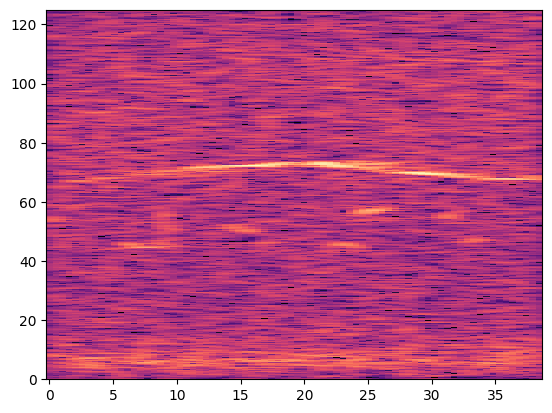

In [54]:
filename = find_audio_file("DBA_9857_922.WAV")
S_db, freqs, times = load_spectrogram(filename)

plt.pcolormesh(times*1000, freqs/1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
plt.ylim(0,125)
plt.show()